# US Alcohol Consumption By State Analysis (1977-2023)

- This Jupyter Notebook aims to explore the dataset provided by the National Institute on Alcohol Abuse and Alcoholism (NIAAA) based in the US through its Alcohol Epidemiologic Data System (AEDS).
- The dataset analyzed in this notebook provides time-series information on the consumption of different alcohol types in the United States between 1977 and 2023.
- We will try to find patterns and actionable insights through data processing, analysis, and visualization.

## Part 1: Importing the Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
path = '/kaggle/input/datasets/sanaijlalshahrukh/us-alcohol-consumption-by-state-19772023/niaaa_apparent_per_capita_consumption_1977_2023.csv'
df = pd.read_csv(path)
df.head()

,state,state_name,year,ethanol_beer_gallons_per_capita,ethanol_wine_gallons_per_capita,ethanol_spirit_gallons_per_capita,ethanol_all_drinks_gallons_per_capita,number_of_beers,number_of_glasses_wine,number_of_shots_liquor,number_of_drinks_total
0,alabama,Alabama,1977,0.97,0.12,0.82,1.92,229.9259,23.8140,170.2514,409.6000
1,alabama,Alabama,1978,0.95,0.12,0.85,1.92,225.1852,23.8140,176.4801,409.6000
2,alabama,Alabama,1979,0.96,0.12,0.82,1.90,227.5556,23.8140,170.2514,405.3333
3,alabama,Alabama,1980,0.95,0.16,0.74,1.86,225.1852,31.7519,153.6415,396.8000
4,alabama,Alabama,1981,1.00,0.19,0.73,1.91,237.0370,37.7054,151.5653,407.4667


In [3]:
df = df.drop_duplicates()

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2632 entries, 0 to 2631
Data columns (total 11 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   state                                  2632 non-null   object 
 1   state_name                             2632 non-null   object 
 2   year                                   2632 non-null   int64  
 3   ethanol_beer_gallons_per_capita        2632 non-null   float64
 4   ethanol_wine_gallons_per_capita        2632 non-null   float64
 5   ethanol_spirit_gallons_per_capita      2632 non-null   float64
 6   ethanol_all_drinks_gallons_per_capita  2632 non-null   float64
 7   number_of_beers                        2632 non-null   float64
 8   number_of_glasses_wine                 2632 non-null   float64
 9   number_of_shots_liquor                 2632 non-null   float64
 10  number_of_drinks_total                 2632 non-null   float64
dtypes: f

In [5]:
objects = ['state', 'state_name']
for obj in objects:
    print(df[obj].value_counts())
    print()

state
alabama                 47
alaska                  47
arizona                 47
arkansas                47
california              47
colorado                47
connecticut             47
delaware                47
district of columbia    47
florida                 47
georgia                 47
hawaii                  47
idaho                   47
illinois                47
indiana                 47
iowa                    47
kansas                  47
kentucky                47
louisiana               47
maine                   47
maryland                47
massachusetts           47
michigan                47
midwest region          47
minnesota               47
mississippi             47
missouri                47
montana                 47
nebraska                47
nevada                  47
new hampshire           47
new jersey              47
new mexico              47
new york                47
north carolina          47
north dakota            47
northeast region      

The column 'state' contains redundant and unnecessary information, so I will delete it from the dataset.

In [6]:
df = df.drop('state', axis=1)

## Part 2: Exploratory Data Analysis

In this EDA, I'll try to answer the following questions using NIAAA's data:
- How many drinks and how much pure ethanol do Americans drink every year on average?
- Which states consume the most alcohol every year since 2020, on average?
- How has the consumption of alcohol changed between 1977 and 2023 in these states?
- Which drink types (beer, wine, liquors) are consistently drunk above the norm?
- What is the correlation between the consumption of various alcoholic drink types?
- Are there any state-specific factors that could influence higher alcohol intake in the population?

In [7]:
import sqlite3 #importing SQL to efficiently extract valuable insights
import prettytable
prettytable.DEFAULT = 'DEFAULT'
%load_ext sql
%matplotlib inline
con = sqlite3.connect('alcohol_consumption_dataset.db')
%sql sqlite:///alcohol_consumption_dataset.db
df.to_sql('alcohol_usage', con, if_exists='replace', index=False) #importing the dataset from the DataFrame into the SQL database for insight extraction

2632

First, we will use the df.describe method to evaluate the mean alcohol consumption in the United States.

In [8]:
df.describe(include='all')

,state_name,year,ethanol_beer_gallons_per_capita,ethanol_wine_gallons_per_capita,ethanol_spirit_gallons_per_capita,ethanol_all_drinks_gallons_per_capita,number_of_beers,number_of_glasses_wine,number_of_shots_liquor,number_of_drinks_total
count,2632,2632.000000,2632.000000,2632.000000,2632.000000,2632.000000,2632.000000,2632.000000,2632.000000,2632.000000
unique,56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Alabama,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,47,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2000.000000,1.257067,0.353427,0.873017,2.483773,297.971406,70.137458,181.258946,529.871531
std,NaN,13.567238,0.236209,0.182849,0.351801,0.604598,55.990382,36.286332,73.042253,128.980841
min,NaN,1977.000000,0.460000,0.080000,0.360000,1.190000,109.037000,15.876000,74.744500,253.866700
25%,NaN,1988.000000,1.100000,0.220000,0.660000,2.130000,260.740700,43.658900,137.031600,454.400000
50%,NaN,2000.000000,1.240000,0.320000,0.790000,2.370000,293.925900,63.503900,164.022700,505.600000
75%,NaN,2012.000000,1.390000,0.460000,0.990000,2.710000,329.481500,91.286800,205.547400,578.133300


- We can infer that, on average, people in the US tend to drink 2.48 gallons (roughly 11.273 liters) of pure ethanol every year.
- An average American also drinks 529 alcoholic drinks (298 of which are beers) every year.
- We have to be aware of the fact that the data may contain outliers, as both columns have a significant standard deviation (0.6 for ethanol, 128.98 for total drinks).
- To test whether the estimated means are accurate or skewed, I will plot the distribution of the ethanol_all_drinks_gallons_per_capita and number_of_drinks_total categories.

<Axes: xlabel='ethanol_all_drinks_gallons_per_capita', ylabel='Density'>

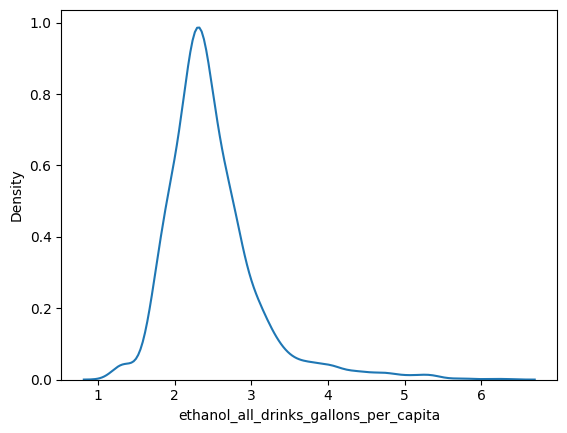

In [9]:
sns.kdeplot(x='ethanol_all_drinks_gallons_per_capita', data=df)

<Axes: xlabel='number_of_drinks_total', ylabel='Density'>

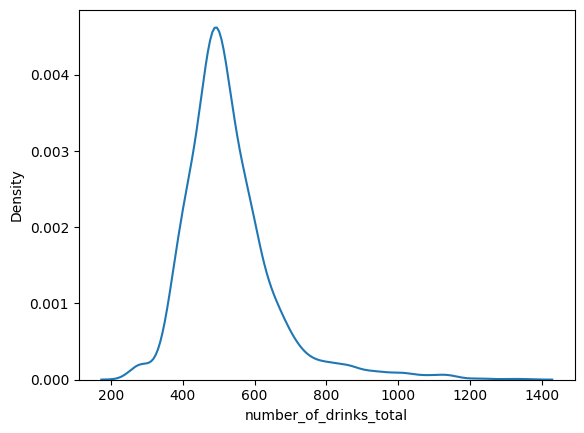

In [10]:
sns.kdeplot(x='number_of_drinks_total', data=df)

- As we can see in these plots, the average values for these columns indeed look to balance around 2.48 gallons of alcohol and 529 alcoholic drinks per year.
- We can observe, however, that both graphs contain outliers in the right tails, which confirms that the dataset is not entirely balanced.
- To estimate the average consumption of alcohol by Americans more accurately, we'll calculate the median of these 2 parameters.

In [11]:
ethanol_med = df['ethanol_all_drinks_gallons_per_capita'].median()
drinks_med = df['number_of_drinks_total'].median()
print(f"The median per capita ethanol consumption in the US in gallons is {ethanol_med}")
print(f"The median number of alcoholic drinks consumed yearly per capita in the US is {drinks_med}")

The median per capita ethanol consumption in the US in gallons is 2.37
The median number of alcoholic drinks consumed yearly per capita in the US is 505.6


- The new estimates of the average alcohol consumption in the US are less sensitive to outliers, and they are not significantly different from the mean estimates.
- We can thus reliably conclude that, on average, Americans drink between 2.37 and 2.48 gallons of pure ethanol and between 505 and 529 alcoholic drinks per year.
- We will now determine which states have a high average alcohol consumption using SQL.

In [12]:
%%sql
SELECT
    state_name,
    ROUND(AVG(ethanol_all_drinks_gallons_per_capita), 2) as avg_ethanol_gallons_per_capita,
    ROUND(AVG(number_of_drinks_total), 2) as avg_total_drinks_per_person
FROM
    alcohol_usage
WHERE
    year >= 2020
GROUP BY
    state_name
ORDER BY
    avg_ethanol_gallons_per_capita DESC
LIMIT 20

 * sqlite:///alcohol_consumption_dataset.db
Done.


state_name,avg_ethanol_gallons_per_capita,avg_total_drinks_per_person
New Hampshire,4.35,928.53
Delaware,4.14,883.2
District Of Columbia,3.99,851.2
Nevada,3.54,755.73
North Dakota,3.3,704.53
Montana,3.25,692.27
Wisconsin,3.15,671.47
Vermont,3.08,656.0
Colorado,3.05,650.13
Wyoming,2.92,622.93


- We can observe that the 20 states in the table drink more alcohol than the average in the US.
- However, the states of New Hampshire, Delaware, Columbia, Nevada, North Dakota, Montana, Wisconsin, Vermont, and Colorado stand out, as their average yearly ethanol consumption per capita is equal to or exceeds 3 gallons per capita.
- Let us now visualize these statistics for the 10 states with the highest alcohol consumption for convenient visual reference.

In [13]:
query = """SELECT
    state_name,
    AVG(ethanol_all_drinks_gallons_per_capita) as avg_ethanol_gallons_per_capita,
    AVG(number_of_drinks_total) as avg_total_drinks_per_person
FROM
    alcohol_usage
WHERE
    year >= 2020
GROUP BY
    state_name
ORDER BY
    avg_ethanol_gallons_per_capita DESC
LIMIT 10"""
high_alc = pd.read_sql_query(query, con)

Text(0.5, 0.98, '10 States in the US with the highest alcohol consumption per person')

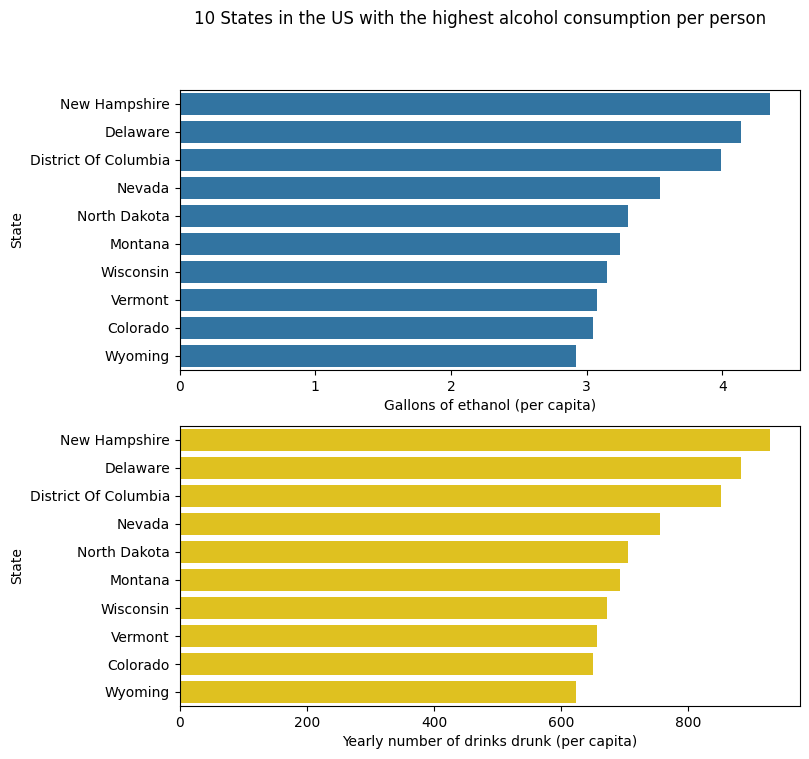

In [14]:
fig, (ax1, ax2) = plt.subplots(2, figsize = (8, 8))
sns.barplot(x='avg_ethanol_gallons_per_capita', y='state_name', data = high_alc, ax = ax1)
ax1.set(xlabel='Gallons of ethanol (per capita)', ylabel = 'State')
sns.barplot(x='avg_total_drinks_per_person', y='state_name', data = high_alc, color='gold', ax = ax2)
ax2.set(xlabel = 'Yearly number of drinks drunk (per capita)', ylabel = 'State')
fig.suptitle("10 States in the US with the highest alcohol consumption per person")

Let's now focus on finding out how alcohol consumption has changed in these states over the period of 1977-2023.

Text(0.5, 0.98, 'Alcohol Consumption by Year in the United States (gallons per capita)')

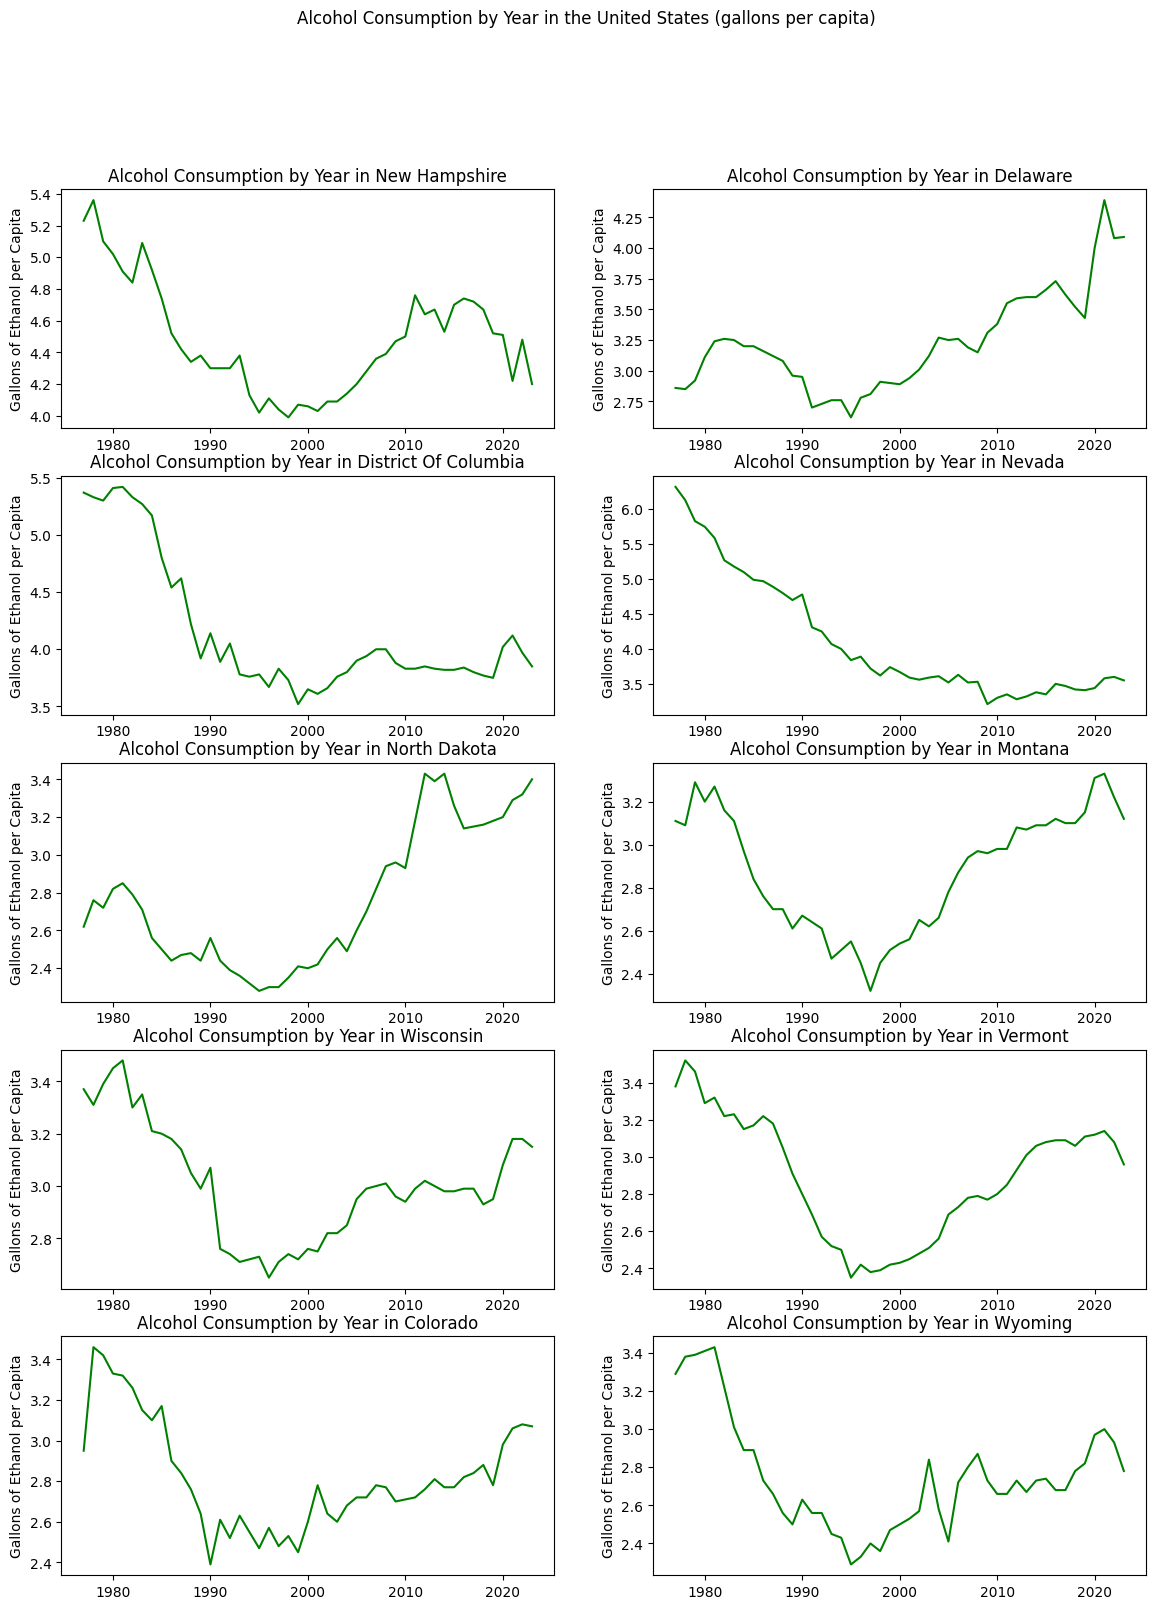

In [15]:
states = ['New Hampshire', 'Delaware', 'District Of Columbia', 'Nevada', 'North Dakota', 'Montana', 'Wisconsin', 'Vermont', 'Colorado', 'Wyoming']
fig, axs = plt.subplots(5,2,figsize=(14,18))
counter = 0
for i in range(5):
    for j in range(2):
        state_df = df[df['state_name'] == states[counter]]
        sns.lineplot(x='year', y='ethanol_all_drinks_gallons_per_capita', data=state_df, color='green', ax=axs[i][j])
        axs[i][j].set(xlabel = "", ylabel = "Gallons of Ethanol per Capita")
        axs[i][j].set_title(f"Alcohol Consumption by Year in {states[counter]}")
        counter+=1
fig.suptitle("Alcohol Consumption by Year in the United States (gallons per capita)")

- Based on this visualization, we can see that alcohol consumption was relatively higher in the beginning of the 1980s for the majority of the 10 states than in the 2020s.
- However, some states show an unusual or the exact opposite pattern.
- In Delaware and North Dakota, the consumption of alcohol relatively increased since the 1980s
- In Montana, the average ethanol consumption per capita rate is roughly the same in the 2020s as it was in the beginning of the 1980s.
- Interestingly, all states in the visualization share the same pattern of having minimal alcohol consumption between the 1990s and 2000. This suggests that an externality caused either a decrease in demand, supply, or both, in that period.

We will now explore the details regarding various alcoholic beverage types, how much they are consumed in the United States, and how their consumption has changed over time.

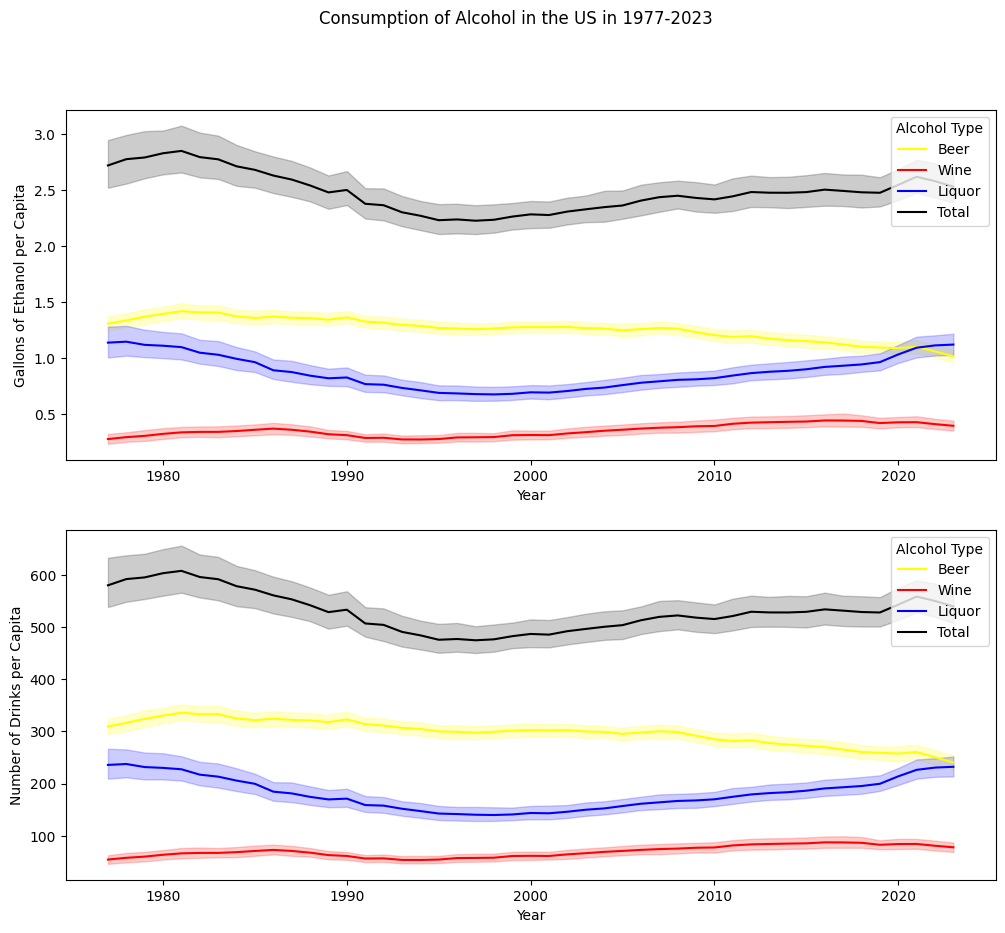

In [16]:
fig, (ax1, ax2) = plt.subplots(2, figsize=(12,10))
sns.lineplot(x = "year", y = "ethanol_beer_gallons_per_capita", label='Beer', data=df, color="yellow", ax=ax1)
sns.lineplot(x = "year", y = "ethanol_wine_gallons_per_capita", label = 'Wine', data=df, color="red", ax=ax1)
sns.lineplot(x = "year", y = "ethanol_spirit_gallons_per_capita", label = 'Liquor', data=df, color="blue", ax=ax1)
sns.lineplot(x = "year", y = "ethanol_all_drinks_gallons_per_capita", label = 'Total', data=df, color="black", ax=ax1)
sns.lineplot(x = "year", y = "number_of_beers", data=df, label='Beer',  color="yellow", ax=ax2)
sns.lineplot(x = "year", y = "number_of_glasses_wine", data=df, label='Wine', color="red", ax=ax2)
sns.lineplot(x = "year", y = "number_of_shots_liquor", data=df, label='Liquor', color="blue", ax=ax2)
sns.lineplot(x = "year", y = "number_of_drinks_total", data=df, label='Total', color="black", ax=ax2)
ax1.set(xlabel = "Year", ylabel="Gallons of Ethanol per Capita")
ax2.set(xlabel='Year', ylabel='Number of Drinks per Capita')
fig.suptitle('Consumption of Alcohol in the US in 1977-2023')
ax1.legend(title='Alcohol Type', loc='upper right')
ax2.legend(title='Alcohol Type', loc='upper right')

- Based on this graph, we can conclude that the average alcohol consumption per capita in the US has not changed significantly since 1977, although it did decrease slightly after the base year.
- Wine is consistently the least popular drink type in the US.
- Beer is the most popular drink in the US, and its consumption has remained relatively stable until the year 2010, since which it has slowly declined.
- Liquor has experienced a decline in consumption between the 1980s and 2000, but has gradually increased in popularity after hitting its minimum in 2000.

Text(0.5, 1.0, 'Correlation in Consumption of Alcohol Types in the US')

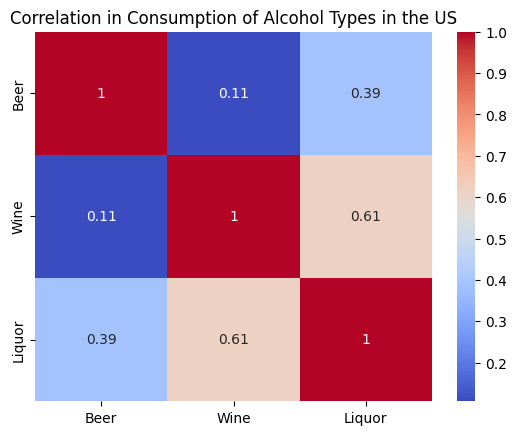

In [17]:
numerical_df = df[["number_of_beers",
                   "number_of_glasses_wine",
                   "number_of_shots_liquor"
]].rename(columns = {
    "number_of_beers": "Beer",
    "number_of_glasses_wine": "Wine",
    "number_of_shots_liquor": "Liquor"
})
sns.heatmap(numerical_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation in Consumption of Alcohol Types in the US")

- In this correlation heatmap, we can see that Americans tend to consume more wine and beer as they drink more liquor (0.61 and 0.39 correlation coefficients, respectively).
- The correlation between wine and beer is very weak - the coefficient is just 0.11.
- It is important to note that *correlation here does not imply causation.*
- What it means is that there is a tendency for Americans to drink more types of alcohol as they consume more liquor.

## Conclusion

We have discovered multiple valuable insights while analyzing NIAAA's time-series data:
- On average, Americans drink between 2.37 and 2.48 gallons of pure ethanol and between 505 and 529 alcoholic drinks per year.
- The average consumption of alcohol per capita has not changed significantly from 1977 to 2023, although it did experience a slight decrease relative to the base year.
- The top 10 states in terms of alcohol consumption are New Hampshire, Delaware, Columbia, Nevada, North Dakota, Montana, Wisconsin, Vermont, Colorado, and Wyoming.
- In the first 9 of these states, the residents drink 3 or more gallons of pure ethanol every year on average.
- Consumption of alcohol has been at its lowest point in 2020
- Beer is the most popular alcoholic drink in the US, although its average consumption has been gradually declining since 2010.
- On the other hand, spirits and liquor have steadily grown in consumption since 2010.
- Americans tend to drink more beer and wine as they drink more liquor (0.39 and 0.61 correlation coefficients, respectively), but the correlation between wine and beer is weak.
- Although most states experienced a relative decline in alcohol usage per capita, some states, such as North Dakota and Delaware, show the opposite trend. Further research with more detailed datasets is necessary to assess why this trend is occurring.